# 03 - Model results: is the score actually useful?

Produced by `scripts/train_model.py`. Protocol (all time-based, no random splits):
- **fit** = earlier train snapshots, **validation** = the last train snapshot (hyper-parameters, calibration, importance)
- **final model** = refit on all train snapshots; **test** = a later snapshot, evaluated once.

Candidates: *mean* (constant), *last_90d_spend* (naive: next quarter = last quarter), *ridge* (linear on
quantile-transformed features), *gbm* (HistGradientBoosting). All fit `log1p(spend)`; money predictions are rescaled by one
calibration factor fit on validation so totals match.

In [2]:
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.width", 140)
M = json.load(open("../models/metrics.json"))
P = pd.read_parquet("../models/test_predictions.parquet")
print(M["model_version"], "|", M["best_params"])
print(M["data"])

gbm-20261002-203929 | {'learning_rate': 0.05, 'max_leaf_nodes': 8, 'max_iter': 150, 'min_samples_leaf': 40, 'l2_regularization': 1.0}
{'train_cutoffs': ['2010-09-14', '2010-12-13', '2011-03-13'], 'validation_cutoff': '2011-06-11', 'test_cutoff': '2011-09-09', 'n_fit_rows': 12311, 'n_val_rows': 4976, 'n_train_rows': 17287, 'n_test_rows': 5278}


## 1. Scoreboard

In [3]:
cols = ["mae", "rmse", "rmsle", "spearman", "auc_will_buy", "top_decile_lift", "calibration_ratio"]
pd.concat({"validation": pd.DataFrame(M["validation"]).T[cols], "test": pd.DataFrame(M["test"]).T[cols]}).round(3)

mae      rmse  rmsle  spearman  auc_will_buy  top_decile_lift  calibration_ratio
validation mean            572.844  2002.798  5.095       NaN           NaN            1.436              1.364
           last_90d_spend  284.722  1352.372  3.085     0.501         0.752            6.402              1.074
           ridge           382.397  5767.833  2.970     0.535         0.808            6.429              1.000
           gbm             305.303  1425.986  2.696     0.556         0.820            6.522              1.000
test       mean            662.980  3201.591  4.619       NaN           NaN            1.257              0.786
           last_90d_spend  417.274  2195.670  3.271     0.480         0.707            5.581              0.644
           ridge           506.196  3854.157  2.831     0.555         0.786            5.628              0.866
           gbm             454.531  2213.628  2.625     0.576         0.799            5.751              0.786

How to read it:
- **Spearman / AUC / top-decile lift** = ranking quality. This is what targeting decisions (who gets the offer) depend on.
- **MAE / RMSE / RMSLE** = how close the money amount is.
- **calibration_ratio** = mean predicted / mean actual (1.0 = totals are right). This matters for budgeting.
- Validation vs test gap = how much the model degrades on the future.

## 2. Calibration by predicted decile (test)

,pred,actual,n
decile,,,
1,1.7,29.6,528
2,3.2,56.9,528
3,5.1,112.8,528
4,6.9,118.4,527
5,10.1,181.9,528
6,15.1,231.0,528
7,28.7,389.8,527
8,69.9,450.3,528
9,226.4,720.3,528


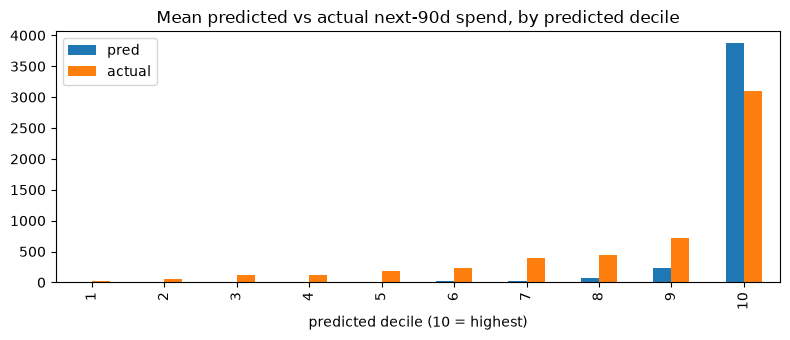

In [4]:
P["decile"] = pd.qcut(P.pred_gbm.rank(method="first"), 10, labels=False) + 1
c = P.groupby("decile").agg(pred=("pred_gbm", "mean"), actual=("actual", "mean"), n=("actual", "size"))
ax = c[["pred", "actual"]].plot.bar(figsize=(8, 3.5), title="Mean predicted vs actual next-90d spend, by predicted decile")
plt.xlabel("predicted decile (10 = highest)"); plt.tight_layout(); c.round(1)

## 3. Cumulative gains: if we target the top X% by score, what share of future spend do we reach?

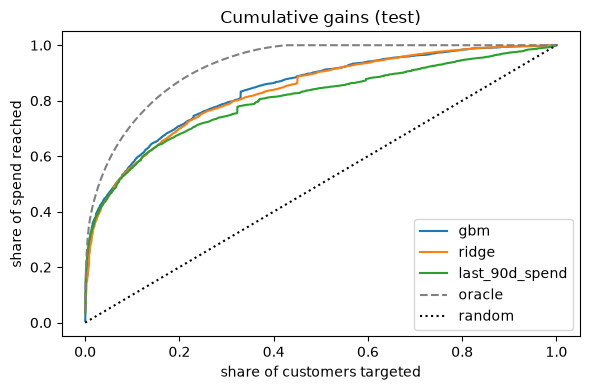

In [5]:
def gains(score, actual):
    o = np.argsort(-np.asarray(score), kind="stable"); cum = np.cumsum(np.asarray(actual)[o]) / np.sum(actual)
    return np.arange(1, len(o) + 1) / len(o), cum
plt.figure(figsize=(6, 4))
for k in ["pred_gbm", "pred_ridge", "pred_last_90d_spend"]:
    x, y = gains(P[k], P.actual); plt.plot(x, y, label=k.replace("pred_", ""))
x, y = gains(P.actual, P.actual); plt.plot(x, y, "--", color="grey", label="oracle")
plt.plot([0, 1], [0, 1], ":", color="black", label="random"); plt.legend(); plt.xlabel("share of customers targeted"); plt.ylabel("share of spend reached")
plt.title("Cumulative gains (test)"); plt.tight_layout()

## 4. Where does it do well or badly? (segments)

In [6]:
P["freq_seg"] = pd.cut(P.frequency, [0, 1, 3, 8, np.inf], labels=["1 order", "2-3", "4-8", "9+"])
P["recency_seg"] = pd.cut(P.recency_days, [-1, 30, 90, 180, np.inf], labels=["<30d", "30-90d", "90-180d", ">180d"])
def seg(col):
    return P.groupby(col, observed=True).agg(n=("actual", "size"), actual=("actual", "mean"), pred=("pred_gbm", "mean"),
        mae=("actual", lambda s: np.mean(np.abs(s - P.loc[s.index, "pred_gbm"]))))
display(seg("freq_seg").round(1)); display(seg("recency_seg").round(1))

,n,actual,pred,mae
freq_seg,,,,
1 order,1577,102.3,7.0,104.5
2-3,1473,233.9,20.8,231.5
4-8,1324,385.2,86.2,359.1
9+,904,2024.3,2303.5,1568.4


,n,actual,pred,mae
recency_seg,,,,
<30d,932,1718.1,1995.4,1418.1
30-90d,960,670.8,328.5,506.3
90-180d,887,328.9,52.7,311.6
>180d,2499,123.6,6.5,126.0


## 5. What drives the score? (permutation importance on validation)

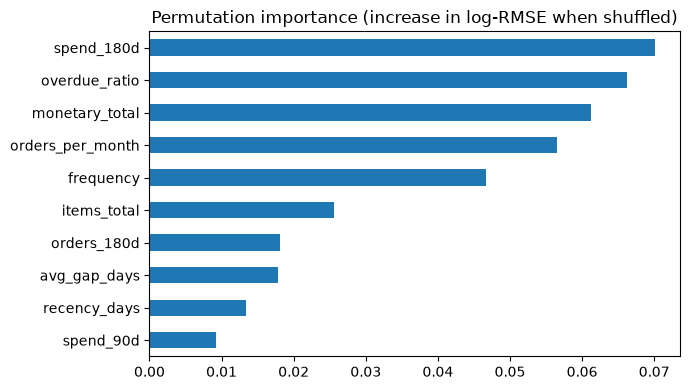

In [7]:
pd.Series(M["permutation_importance_top10"]).sort_values().plot.barh(figsize=(7, 4), title="Permutation importance (increase in log-RMSE when shuffled)")
plt.tight_layout()

## 6. Hyper-parameter grid (validation, log-scale RMSE)

In [8]:
g = pd.DataFrame([{**r["params"], "val_rmse_log": r["val_rmse_log"]} for r in M["grid_results"]]).sort_values("val_rmse_log")
g.round(4)

,learning_rate,max_leaf_nodes,max_iter,min_samples_leaf,l2_regularization,val_rmse_log
0,0.05,8,150,40,1.0,2.3207
1,0.05,8,300,40,1.0,2.3207
2,0.05,16,150,40,1.0,2.3217
3,0.05,16,300,40,1.0,2.3217
4,0.10,8,150,40,1.0,2.3225
5,0.10,8,300,40,1.0,2.3225
6,0.10,16,150,40,1.0,2.3298
7,0.10,16,300,40,1.0,2.3298


## 7. Reading the results (fill in with your real numbers)
1. Does the GBM beat `last_90d_spend` and `ridge` on ranking *and* on money error? If the gap is small, a simple rule is a legitimate answer.
2. Is the test gap vs validation large? A shifted season (for example the holiday peak) is a *data drift* story, not a model bug.
3. Which segments are worst? One-order customers usually are: little history, nothing to learn from.
4. Calibration ratio far from 1 means totals are off even if ranking is fine. Decide which one the business needs.

**Ideas if you want to improve it (not required for the exercise):** two-part model (P(buy) x E[spend | buy]), quantile/Tweedie loss,
product-category features, a longer history of snapshots, MLflow for experiment tracking and a model registry.